# Исследование сгенерированного QA-датасета

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src.config import get_cfg, paths_from_cfg
from src.eval_data import load_qa_dataset_from_jsonl

cfg = get_cfg()
EVAL_DATASETS_DIR = paths_from_cfg(cfg)["eval_datasets_dir"]

## Загрузка датасета

In [2]:
data = load_qa_dataset_from_jsonl(EVAL_DATASETS_DIR / "eval_dataset.jsonl")
df = pd.DataFrame(data)
print(f"Загружено сэмплов: {len(data)}")

Загружено сэмплов: 200


## Статистика

Распределение по типу вопроса (single_hop/multi_hop), количество эталонных ответов и gold-контекстов.

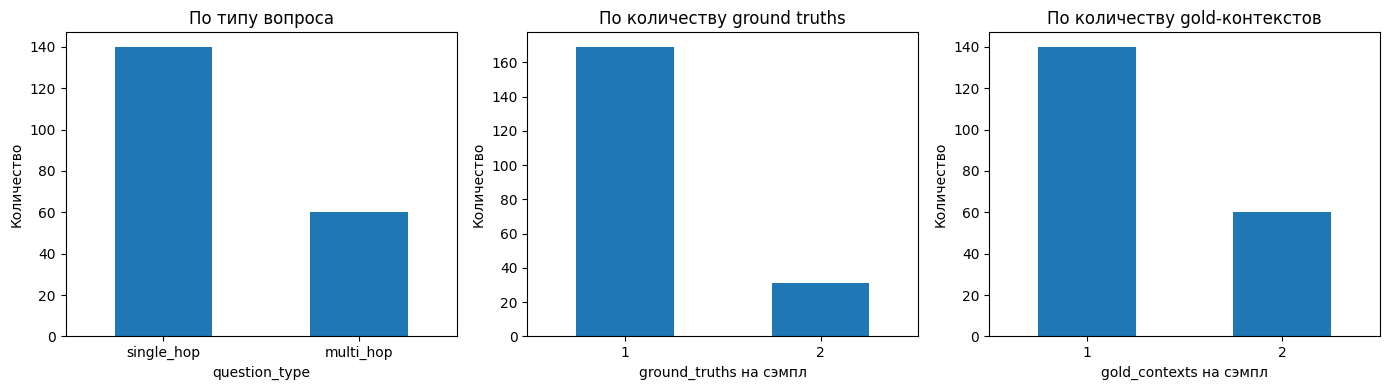

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["question_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("По типу вопроса")
axes[0].set_xlabel("question_type")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=0)

df["ground_truths"].apply(len).value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("По количеству ground truths")
axes[1].set_xlabel("ground_truths на сэмпл")
axes[1].set_ylabel("Количество")
axes[1].tick_params(axis="x", rotation=0)

df["gold_contexts"].apply(len).value_counts().sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("По количеству gold-контекстов")
axes[2].set_xlabel("gold_contexts на сэмпл")
axes[2].set_ylabel("Количество")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Анализ длин текстов

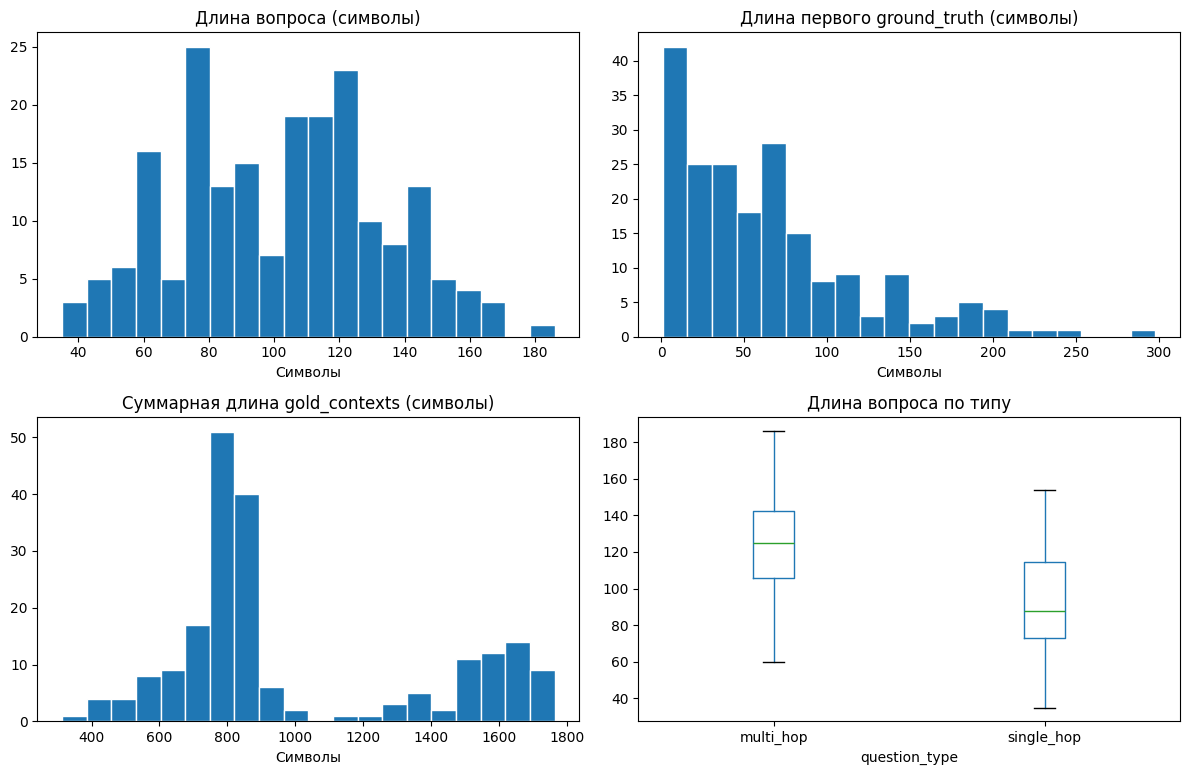

In [4]:
df["q_len"] = df["question"].str.len()
df["gt_len"] = df["ground_truths"].apply(lambda x: len(x[0]) if x else 0)
df["ctx_len"] = df["gold_contexts"].apply(lambda g: sum(len(c.get("text") or "") for c in (g or [])))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df["q_len"].hist(ax=axes[0, 0], bins=20, edgecolor="white")
axes[0, 0].set_title("Длина вопроса (символы)")
axes[0, 0].set_xlabel("Символы")
axes[0, 0].grid(False)

df["gt_len"].hist(ax=axes[0, 1], bins=20, edgecolor="white")
axes[0, 1].set_title("Длина первого ground_truth (символы)")
axes[0, 1].set_xlabel("Символы")
axes[0, 1].grid(False)

df["ctx_len"].hist(ax=axes[1, 0], bins=20, edgecolor="white")
axes[1, 0].set_title("Суммарная длина gold_contexts (символы)")
axes[1, 0].set_xlabel("Символы")
axes[1, 0].grid(False)

df.boxplot(column="q_len", by="question_type", ax=axes[1, 1])
axes[1, 1].set_title("Длина вопроса по типу")
axes[1, 1].set_xlabel("question_type")
axes[1, 1].grid(False)
plt.suptitle("")
plt.tight_layout()
plt.show()

- Длины вопросов и ответов умеренные (десятки - сотни символов), суммарная длина gold_contexts - порядка 300-1800 символов.
- multi_hop ожидаемо длинее, т.к. сложнее и должны охватывать несколько чанков.

### Покрытие игр

In [5]:
def _get_games(gold_contexts):
    ctxs = gold_contexts or []
    games = []
    for c in ctxs:
        meta = (c.get("metadata") or {}) if isinstance(c, dict) else {}
        gt = meta.get("game_titles")
        if isinstance(gt, list):
            games.extend(gt)
        elif isinstance(gt, str) and gt.strip():
            games.append(gt)
    return list(dict.fromkeys(games))

df["games"] = df["gold_contexts"].apply(_get_games)
game_counts = df.explode("games").groupby("games").size().sort_values(ascending=False)

print(f"Всего уникальных игр: {len(game_counts)}")

Всего уникальных игр: 198


### Паттерны в вопросах

Распределение первых триграмм в вопросах.

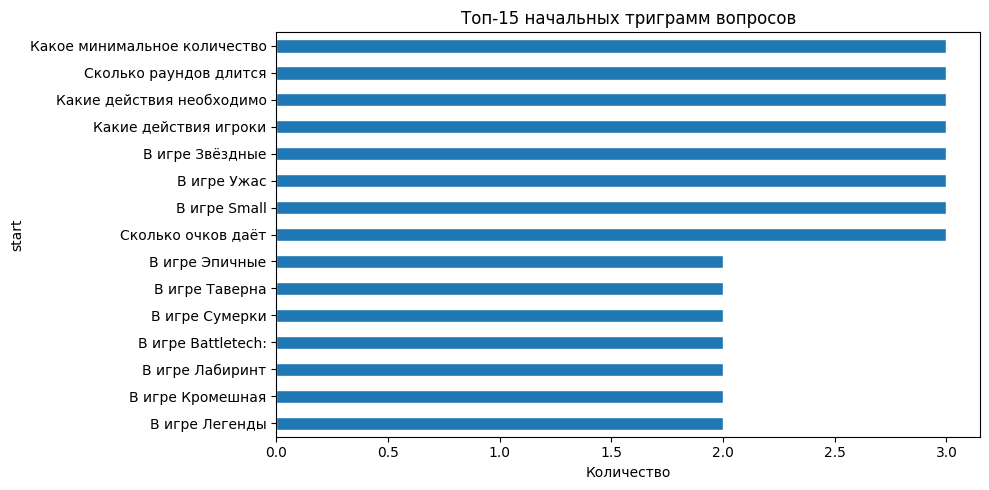

In [6]:
import re

def first_tokens(s, n=3):
    words = re.findall(r"\S+", (s or "").strip())
    return " ".join(words[:n]) if words else ""

df["start"] = df["question"].apply(first_tokens)
top_starts = df["start"].value_counts().head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
top_starts.plot(kind="barh", ax=ax, edgecolor="white")
ax.set_title("Топ-15 начальных триграмм вопросов")
ax.set_xlabel("Количество")
ax.grid(False)
plt.tight_layout()
plt.show()

- Частые слова/фразы: «Сколько», «Какие», «В игре», «Как» - типичны для вопросов о правилах настольных игр.
- Часто вопросы начинаются с «В игре ...», т.к. при генерации датасета эти фразы проставлялись в вопросах, где LLM сама не указывала игру.

### Примеры выбросов

Самые короткие и длинные вопросы.

In [7]:
# Топ-3 самых коротких и длинных вопроса (по символам)
if "q_len" not in df.columns:
    df["q_len"] = df["question"].str.len()
sorted_df = df.sort_values("q_len")

def _preview(q, max_len=100):
    return q[:max_len] + ("..." if len(q) > max_len else "")

print("Самые короткие вопросы:")
for _, r in sorted_df.head(3).iterrows():
    print(f"  [{r['q_len']} симв.] {_preview(r['question'])}")
print("\nСамые длинные вопросы:")
for _, r in sorted_df.tail(3).iloc[::-1].iterrows():
    print(f"  [{r['q_len']} симв.] {_preview(r['question'])}")

Самые короткие вопросы:
  [35 симв.] Сколько раундов длится игра Сабика?
  [37 симв.] Какова цель игры Аргент. Совет магов?
  [39 симв.] Сколько раундов длится игра Совпадение?

Самые длинные вопросы:
  [186 симв.] В игре Моджо Какие действия выполняются при игре карты с номиналом выше верхней карты стопки сброса ...
  [167 симв.] В игре Волшебник Изумрудного города Какое действие происходит при попадании фишки магии на клетку с ...
  [166 симв.] В игре Вечная зима: Палеоиндейцы Сколько орудий требуется для размещения первой стоянки во время фаз...


- Разброс в длине (~5×) отражает разную степень самодостаточности: короткие вопросы компактны и фактоидны, длинные явно указывают конкретный сценарий.
- Для RAG важно корректно обрабатывать оба типа формулировок - и краткие, и развёрнутые.

## Общий вывод о пригодности датасета для оценки

Датасет пригоден для оценки RAG-систем по правилам настольных игр так как:

- Структура соответствует типичному формату QA: вопросы, эталонные ответы, gold-контексты с метаданными.
- Покрыто множество игр.
- Формулировки разнообразны (короткие/длинные, разные паттерны).
- Разделение single_hop / multi_hop даёт возможность оценивать сложность задач по отдельности.